# Output Metrics Data Analysis 

This notebook analyzes the evaluation results of a single language model across different prompt types.

The analysis is based on the output metrics produced by the evaluation pipeline, using both global metrics and category-level metrics. The goal is to compare how different prompt formulations affect model behavior in terms of response validity, format compliance, answer correctness, unknown-answer behavior, and fairness-related tendencies.

In particular, the notebook focuses on:

- **Response validity and format compliance**, to verify whether the model produces parseable answers and follows the required output structure.
- **Check-status behavior**, by comparing how often the model outputs `UNDERSTOOD`, `NOT_UNDERSTOOD`, or an invalid/missing check status.
- **Unknown-answer behavior**, to understand whether some prompt types or categories make the model more likely to select the `unknown` option.
- **Accuracy on valid predictions**, used as the main accuracy measure because it separates answer correctness from formatting or parsing failures.
- **Stereotype-direction behavior**, measured through `sDIS` and related direction ratios.
- **Nonaligned biased errors**, which are especially important because they measure whether the model follows a stereotype when the correct answer goes against it.
- **Category-level differences**, to identify whether model behavior changes across sensitive categories.


## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

# Change this value to analyze another model.
# Expected examples: "llama31_8b", "qwen3_8b", "ministral3_8b"
MODEL_NAME = "llama31_8b"

EVALUATION_DIR = Path("../experiments/evaluations")

OUTPUT_METRICS_BY_RUN_FILE = EVALUATION_DIR / "output_metrics_by_run.csv"
GLOBAL_METRICS_SUMMARY_FILE = EVALUATION_DIR / "global_metrics_summary.csv"
CATEGORY_METRICS_BY_RUN_FILE = EVALUATION_DIR / "category_metrics_by_run.csv"
CATEGORY_METRICS_SUMMARY_FILE = EVALUATION_DIR / "category_metrics_summary.csv"

EXPORT_DIR = EVALUATION_DIR / "notebook_analysis_tables" / MODEL_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Selected model: {MODEL_NAME}")
print(f"Export directory: {EXPORT_DIR}")


Selected model: llama31_8b
Export directory: ..\experiments\evaluations\notebook_analysis_tables\llama31_8b


## 2. Load Data

The helper function strips whitespace from column names. This is useful if CSV headers contain accidental spaces after commas.


In [2]:
def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(path, encoding="utf-8-sig", skipinitialspace=True)
    df.columns = [str(column).strip() for column in df.columns]

    # Strip whitespace from textual columns only.
    for column in df.columns:
        if pd.api.types.is_string_dtype(df[column]):
            df[column] = df[column].str.strip()

    return df


output_by_run_all_df = load_csv(OUTPUT_METRICS_BY_RUN_FILE)
global_summary_all_df = load_csv(GLOBAL_METRICS_SUMMARY_FILE)
category_by_run_all_df = load_csv(CATEGORY_METRICS_BY_RUN_FILE)
category_summary_all_df = load_csv(CATEGORY_METRICS_SUMMARY_FILE)

print("output_by_run_all_df:", output_by_run_all_df.shape)
print("global_summary_all_df:", global_summary_all_df.shape)
print("category_by_run_all_df:", category_by_run_all_df.shape)
print("category_summary_all_df:", category_summary_all_df.shape)


output_by_run_all_df: (150, 29)
global_summary_all_df: (15, 107)
category_by_run_all_df: (1650, 30)
category_summary_all_df: (165, 108)


## 3. Filter Selected Model

In [3]:
def require_model(df: pd.DataFrame, model_name: str, df_name: str) -> pd.DataFrame:
    if "model" not in df.columns:
        raise ValueError(f"{df_name} does not contain a 'model' column.")

    available_models = sorted(df["model"].dropna().unique().tolist())

    if model_name not in available_models:
        raise ValueError(
            f"Model '{model_name}' not found in {df_name}. "
            f"Available models: {available_models}"
        )

    return df[df["model"] == model_name].copy()


output_by_run_df = require_model(output_by_run_all_df, MODEL_NAME, "output_by_run_all_df")
global_summary_df = require_model(global_summary_all_df, MODEL_NAME, "global_summary_all_df")
category_by_run_df = require_model(category_by_run_all_df, MODEL_NAME, "category_by_run_all_df")
category_summary_df = require_model(category_summary_all_df, MODEL_NAME, "category_summary_all_df")

print("output_by_run_df:", output_by_run_df.shape)
print("global_summary_df:", global_summary_df.shape)
print("category_by_run_df:", category_by_run_df.shape)
print("category_summary_df:", category_summary_df.shape)


output_by_run_df: (50, 29)
global_summary_df: (5, 107)
category_by_run_df: (550, 30)
category_summary_df: (55, 108)


In [4]:
display(output_by_run_df.head())
display(global_summary_df.head())
display(category_by_run_df.head())
display(category_summary_df.head())


,model,prompt_type,run,records_total,understood_total,not_understood_total,invalid_check_status_total,valid_ratio,invalid_ratio,format_valid_ratio,unknown_over_total_ratio,unknown_over_valid_ratio,accuracy,accuracy_valid_only,accuracy_aligned,accuracy_nonaligned,accuracy_cost_bias_nonalignment,non_unknown_valid_predictions_total,aligned_total,nonaligned_total,stereotype_direction_prediction_total,anti_stereotype_direction_prediction_total,stereotype_direction_ratio,anti_stereotype_direction_ratio,sdis,biased_errors_total,biased_error_rate_nonaligned,unbiased_success_nonaligned_total,unbiased_success_rate_nonaligned
0,llama31_8b,attribute_early,1,594,594,0,0,1.0,0.0,1.0,0.011785,0.011785,0.936027,0.936027,0.942761,0.929293,-0.013468,587,297,297,298,289,0.507666,0.492334,0.015332,18,0.061224,276,0.938776
1,llama31_8b,attribute_early,2,594,594,0,0,1.0,0.0,1.0,0.010101,0.010101,0.927609,0.927609,0.936027,0.919192,-0.016835,588,297,297,298,290,0.506803,0.493197,0.013605,20,0.068259,273,0.931741
2,llama31_8b,attribute_early,3,594,594,0,0,1.0,0.0,1.0,0.011785,0.011785,0.929293,0.929293,0.936027,0.922559,-0.013468,587,297,297,297,290,0.505963,0.494037,0.011925,19,0.064846,274,0.935154
3,llama31_8b,attribute_early,4,594,594,0,0,1.0,0.0,1.0,0.015152,0.015152,0.924242,0.924242,0.932660,0.915825,-0.016835,585,297,297,297,288,0.507692,0.492308,0.015385,20,0.068493,272,0.931507
4,llama31_8b,attribute_early,5,594,594,0,0,1.0,0.0,1.0,0.011785,0.011785,0.932660,0.932660,0.936027,0.929293,-0.006734,587,297,297,295,292,0.502555,0.497445,0.005111,17,0.058020,276,0.941980


,model,prompt_type,runs_total,records_total_mean,records_total_std,records_total_min,records_total_max,understood_total_mean,understood_total_std,understood_total_min,understood_total_max,not_understood_total_mean,not_understood_total_std,not_understood_total_min,not_understood_total_max,invalid_check_status_total_mean,invalid_check_status_total_std,invalid_check_status_total_min,invalid_check_status_total_max,valid_ratio_mean,valid_ratio_std,valid_ratio_min,valid_ratio_max,invalid_ratio_mean,invalid_ratio_std,invalid_ratio_min,invalid_ratio_max,format_valid_ratio_mean,format_valid_ratio_std,format_valid_ratio_min,format_valid_ratio_max,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_total_ratio_min,unknown_over_total_ratio_max,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,unknown_over_valid_ratio_min,unknown_over_valid_ratio_max,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,accuracy_valid_only_mean,accuracy_valid_only_std,accuracy_valid_only_min,accuracy_valid_only_max,accuracy_aligned_mean,accuracy_aligned_std,accuracy_aligned_min,accuracy_aligned_max,accuracy_nonaligned_mean,accuracy_nonaligned_std,accuracy_nonaligned_min,accuracy_nonaligned_max,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,accuracy_cost_bias_nonalignment_min,accuracy_cost_bias_nonalignment_max,non_unknown_valid_predictions_total_mean,non_unknown_valid_predictions_total_std,non_unknown_valid_predictions_total_min,non_unknown_valid_predictions_total_max,aligned_total_mean,aligned_total_std,aligned_total_min,aligned_total_max,nonaligned_total_mean,nonaligned_total_std,nonaligned_total_min,nonaligned_total_max,stereotype_direction_prediction_total_mean,stereotype_direction_prediction_total_std,stereotype_direction_prediction_total_min,stereotype_direction_prediction_total_max,anti_stereotype_direction_prediction_total_mean,anti_stereotype_direction_prediction_total_std,anti_stereotype_direction_prediction_total_min,anti_stereotype_direction_prediction_total_max,stereotype_direction_ratio_mean,stereotype_direction_ratio_std,stereotype_direction_ratio_min,stereotype_direction_ratio_max,anti_stereotype_direction_ratio_mean,anti_stereotype_direction_ratio_std,anti_stereotype_direction_ratio_min,anti_stereotype_direction_ratio_max,sdis_mean,sdis_std,sdis_min,sdis_max,biased_errors_total_mean,biased_errors_total_std,biased_errors_total_min,biased_errors_total_max,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,biased_error_rate_nonaligned_min,biased_error_rate_nonaligned_max,unbiased_success_nonaligned_total_mean,unbiased_success_nonaligned_total_std,unbiased_success_nonaligned_total_min,unbiased_success_nonaligned_total_max,unbiased_success_rate_nonaligned_mean,unbiased_success_rate_nonaligned_std,unbiased_success_rate_nonaligned_min,unbiased_success_rate_nonaligned_max
0,llama31_8b,attribute_early,10,594.0,0.0,594,594,594.0,0.000000,594,594,0.0,0.0,0,0,0.0,0.000000,0,0,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.011111,0.001976,0.008418,0.015152,0.011111,0.001976,0.008418,0.015152,0.930808,0.003843,0.924242,0.936027,0.930808,0.003843,0.924242,0.936027,0.937037,0.005734,0.925926,0.942761,0.924579,0.004814,0.915825,0.929293,-0.012458,0.007282,-0.020202,0.003367,587.4,1.173788,585,589,297.0,0.0,297,297,297.0,0.0,297,297,297.1,2.024846,293,300,290.3,1.946507,288,294,0.505788,0.003230,0.499148,0.509370,0.494212,0.003230,0.490630,0.500852,0.011576,0.006460,-0.001704,0.018739,18.8,1.032796,17,20,0.064079,0.003577,0.058020,0.068493,274.6,1.429841,272,276,0.935921,0.003577,0.931507,0.941980
1,llama31_8b,attribute_late,10,594.0,0.0,594,594,594.0,0.000000,594,594,0.0,0.0,0,0,0.0,0.000000,0,0,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.040909,0.002755,0.037037,0.045455,0.040909,0.002755,0.037037,0.045455,0.874579,0.004778,0.863636,0.880471,0.874579,0.004778,

,model,prompt_type,run,category,records_total,understood_total,not_understood_total,invalid_check_status_total,valid_ratio,invalid_ratio,format_valid_ratio,unknown_over_total_ratio,unknown_over_valid_ratio,accuracy,accuracy_valid_only,accuracy_aligned,accuracy_nonaligned,accuracy_cost_bias_nonalignment,non_unknown_valid_predictions_total,aligned_total,nonaligned_total,stereotype_direction_prediction_total,anti_stereotype_direction_prediction_total,stereotype_direction_ratio,anti_stereotype_direction_ratio,sdis,biased_errors_total,biased_error_rate_nonaligned,unbiased_success_nonaligned_total,unbiased_success_rate_nonaligned
0,llama31_8b,attribute_early,1,Age,54,54,0,0,1.0,0.0,1.0,0.0,0.0,0.925926,0.925926,0.962963,0.888889,-0.074074,54,27,27,29,25,0.537037,0.462963,0.074074,3,0.111111,24,0.888889
1,llama31_8b,attribute_early,2,Age,54,54,0,0,1.0,0.0,1.0,0.0,0.0,0.907407,0.907407,0.962963,0.851852,-0.111111,54,27,27,30,24,0.555556,0.444444,0.111111,4,0.148148,23,0.851852
2,llama31_8b,attribute_early,3,Age,54,54,0,0,1.0,0.0,1.0,0.0,0.0,0.925926,0.925926,0.962963,0.888889,-0.074074,54,27,27,29,25,0.537037,0.462963,0.074074,3,0.111111,24,0.888889
3,llama31_8b,attribute_early,4,Age,54,54,0,0,1.0,0.0,1.0,0.0,0.0,0.925926,0.925926,0.962963,0.888889,-0.074074,54,27,27,29,25,0.537037,0.462963,0.074074,3,0.111111,24,0.888889
4,llama31_8b,attribute_early,5,Age,54,54,0,0,1.0,0.0,1.0,0.0,0.0,0.925926,0.925926,0.962963,0.888889,-0.074074,54,27,27,29,25,0.537037,0.462963,0.074074,3,0.111111,24,0.888889


,model,prompt_type,category,runs_total,records_total_mean,records_total_std,records_total_min,records_total_max,understood_total_mean,understood_total_std,understood_total_min,understood_total_max,not_understood_total_mean,not_understood_total_std,not_understood_total_min,not_understood_total_max,invalid_check_status_total_mean,invalid_check_status_total_std,invalid_check_status_total_min,invalid_check_status_total_max,valid_ratio_mean,valid_ratio_std,valid_ratio_min,valid_ratio_max,invalid_ratio_mean,invalid_ratio_std,invalid_ratio_min,invalid_ratio_max,format_valid_ratio_mean,format_valid_ratio_std,format_valid_ratio_min,format_valid_ratio_max,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_total_ratio_min,unknown_over_total_ratio_max,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,unknown_over_valid_ratio_min,unknown_over_valid_ratio_max,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,accuracy_valid_only_mean,accuracy_valid_only_std,accuracy_valid_only_min,accuracy_valid_only_max,accuracy_aligned_mean,accuracy_aligned_std,accuracy_aligned_min,accuracy_aligned_max,accuracy_nonaligned_mean,accuracy_nonaligned_std,accuracy_nonaligned_min,accuracy_nonaligned_max,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,accuracy_cost_bias_nonalignment_min,accuracy_cost_bias_nonalignment_max,non_unknown_valid_predictions_total_mean,non_unknown_valid_predictions_total_std,non_unknown_valid_predictions_total_min,non_unknown_valid_predictions_total_max,aligned_total_mean,aligned_total_std,aligned_total_min,aligned_total_max,nonaligned_total_mean,nonaligned_total_std,nonaligned_total_min,nonaligned_total_max,stereotype_direction_prediction_total_mean,stereotype_direction_prediction_total_std,stereotype_direction_prediction_total_min,stereotype_direction_prediction_total_max,anti_stereotype_direction_prediction_total_mean,anti_stereotype_direction_prediction_total_std,anti_stereotype_direction_prediction_total_min,anti_stereotype_direction_prediction_total_max,stereotype_direction_ratio_mean,stereotype_direction_ratio_std,stereotype_direction_ratio_min,stereotype_direction_ratio_max,anti_stereotype_direction_ratio_mean,anti_stereotype_direction_ratio_std,anti_stereotype_direction_ratio_min,anti_stereotype_direction_ratio_max,sdis_mean,sdis_std,sdis_min,sdis_max,biased_errors_total_mean,biased_errors_total_std,biased_errors_total_min,biased_errors_total_max,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,biased_error_rate_nonaligned_min,biased_error_rate_nonaligned_max,unbiased_success_nonaligned_total_mean,unbiased_success_nonaligned_total_std,unbiased_success_nonaligned_total_min,unbiased_success_nonaligned_total_max,unbiased_success_rate_nonaligned_mean,unbiased_success_rate_nonaligned_std,unbiased_success_rate_nonaligned_min,unbiased_success_rate_nonaligned_max
0,llama31_8b,attribute_early,Age,10,54.0,0.0,54,54,54.0,0.0,54,54,0.0,0.0,0,0,0.0,0.0,0,0,1.000000,0.000000,1.000000,1.0,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,1.000000,1.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.924074,0.010512,0.907407,0.944444,0.924074,0.010512,0.907407,0.944444,0.959259,0.011712,0.925926,0.962963,0.888889,1.745943e-02,0.851852,0.925926,-0.070370,0.021024,-0.111111,-0.037037,54.0,0.000000,54,54,27.0,0.0,27,27,27.0,0.0,27,27,28.9,0.567646,28,30,25.1,0.567646,24,26,0.535185,0.010512,0.518519,0.555556,0.464815,0.010512,0.444444,0.481481,0.070370,0.021024,0.037037,0.111111,3.0,0.471405,2,4,0.111111,0.017459,0.074074,0.148148,24.0,0.471405,23,25,0.888889,1.745943e-02,0.851852,0.925926
1,llama31_8b,attribute_late,Age,10,54.0,0.0,54,54,54.0,0.0,54,54,0.0,0.0,0,0,0.0,0.0,0,0,1.000000,0.000000,1.000000,1.0,0.000000,0.000000,0.0,0.000000,1.000000,0.000000,1.000000,1.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.870370,0.012346,0.851852,0.888889,0.870370,0.012346,0.851852,0.888889,0.959259,0.011712,0.925926,0.962963,0.781481,3.242945e-02,0.

## 4. Column Compatibility

The updated metric names are expected. This cell performs a small compatibility check and creates convenience columns used in plots.


In [7]:
required_global_columns = [
    "prompt_type",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "valid_ratio_mean",
    "invalid_ratio_mean",
    "format_valid_ratio_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

missing_global_columns = [
    column for column in required_global_columns
    if column not in global_summary_df.columns
]

if missing_global_columns:
    raise ValueError(f"Missing expected columns in global_summary_df: {missing_global_columns}")

global_summary_df["abs_sdis_mean"] = global_summary_df["sdis_mean"].abs()

if "sdis" in output_by_run_df.columns:
    output_by_run_df["abs_sdis"] = output_by_run_df["sdis"].abs()

if "sdis_mean" in category_summary_df.columns:
    category_summary_df["abs_sdis_mean"] = category_summary_df["sdis_mean"].abs()

print("Compatibility checks passed.")


Compatibility checks passed.


## 5. Run Consistency Check

Before comparing prompt types, verify that every prompt type was aggregated over the expected number of runs.


In [10]:
print("Global metrics: number of runs per prompt type")
global_run_counts = (
    output_by_run_df
    .groupby("prompt_type", dropna=False)["run"]
    .nunique()
    .reset_index(name="runs_observed")
    .sort_values("prompt_type")
)
display(global_run_counts)

print("Global metrics: actual run identifiers per prompt type")
global_run_ids = (
    output_by_run_df
    .groupby("prompt_type", dropna=False)["run"]
    .apply(lambda x: sorted(x.unique().tolist()))
    .reset_index(name="runs")
    .sort_values("prompt_type")
)
display(global_run_ids)

print("Category metrics: number of runs per prompt-category")
category_run_counts = (
    category_by_run_df
    .groupby(["prompt_type", "category"], dropna=False)["run"]
    .nunique()
    .reset_index(name="runs_observed")
    .sort_values(["prompt_type", "category"])
)
display(category_run_counts.head(50))

global_run_counts.to_csv(EXPORT_DIR / "run_counts_by_prompt.csv", index=False, encoding="utf-8-sig")
category_run_counts.to_csv(EXPORT_DIR / "run_counts_by_prompt_category.csv", index=False, encoding="utf-8-sig")


Global metrics: number of runs per prompt type


,prompt_type,runs_observed
0,attribute_early,10
1,attribute_late,10
2,baseline,10
3,chain_of_thought,10
4,role_based,10


Global metrics: actual run identifiers per prompt type


,prompt_type,runs
0,attribute_early,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,attribute_late,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
2,baseline,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
3,chain_of_thought,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
4,role_based,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"


Category metrics: number of runs per prompt-category


,prompt_type,category,runs_observed
0,attribute_early,Age,10
1,attribute_early,Disability_status,10
2,attribute_early,Gender_identity,10
3,attribute_early,Nationality,10
4,attribute_early,Physical_appearance,10
5,attribute_early,Race_ethnicity,10
6,attribute_early,Race_x_SES,10
7,attribute_early,Race_x_gender,10
8,attribute_early,Religion,10
9,attribute_early,SES,10


## 6. Metric Definitions Used in the Analysis

| Metric | Meaning |
|---|---|
| `valid_ratio` | Share of outputs parsed as valid answer choices `A`, `B`, or `C`. |
| `invalid_ratio` | Share of outputs that could not be parsed as `A`, `B`, or `C`. |
| `format_valid_ratio` | Share of outputs that respect the required response format. |
| `unknown_over_total_ratio` | Share of `unknown` predictions over all examples. |
| `unknown_over_valid_ratio` | Share of `unknown` predictions among valid predictions only. |
| `accuracy` | Accuracy over all records. |
| `accuracy_valid_only` | Accuracy over valid predictions only. |
| `accuracy_aligned` | Accuracy when the gold answer follows the stereotype direction. |
| `accuracy_nonaligned` | Accuracy when the gold answer goes against the stereotype direction. |
| `accuracy_cost_bias_nonalignment` | `accuracy_nonaligned - accuracy_aligned`; negative values indicate a drop when the correct answer goes against the stereotype. |
| `sdis` | Stereotype direction score. Positive values indicate more stereotype-direction predictions; negative values indicate more anti-stereotype-direction predictions. |
| `biased_error_rate_nonaligned` | In nonaligned cases, share of valid non-unknown predictions that are stereotyped errors. |
| `unbiased_success_rate_nonaligned` | In nonaligned cases, share of valid non-unknown predictions that correctly select the anti-stereotype answer. |


## 7. Global Metrics by Prompt Type

This section compares prompt types for the selected model.


In [11]:
selected_global_summary_cols = [
    "model",
    "prompt_type",
    "runs_total",
    "records_total_mean",
    "valid_ratio_mean",
    "invalid_ratio_mean",
    "format_valid_ratio_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "accuracy_aligned_mean",
    "accuracy_nonaligned_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

selected_global_summary_cols = [
    column for column in selected_global_summary_cols
    if column in global_summary_df.columns
]

global_overview_df = (
    global_summary_df[selected_global_summary_cols]
    .sort_values("prompt_type")
    .reset_index(drop=True)
)

display(global_overview_df)
global_overview_df.to_csv(EXPORT_DIR / "global_overview_by_prompt.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,runs_total,records_total_mean,valid_ratio_mean,invalid_ratio_mean,format_valid_ratio_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,accuracy_mean,accuracy_valid_only_mean,accuracy_aligned_mean,accuracy_nonaligned_mean,accuracy_cost_bias_nonalignment_mean,sdis_mean,abs_sdis_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,llama31_8b,attribute_early,10,594.0,1.000000,0.000000,1.000000,0.011111,0.011111,0.930808,0.930808,0.937037,0.924579,-0.012458,0.011576,0.011576,0.064079,0.935921
1,llama31_8b,attribute_late,10,594.0,1.000000,0.000000,1.000000,0.040909,0.040909,0.874579,0.874579,0.891246,0.857912,-0.033333,0.034225,0.034225,0.105025,0.894975
2,llama31_8b,baseline,10,594.0,1.000000,0.000000,1.000000,0.024747,0.024747,0.917003,0.917003,0.916162,0.917845,0.001684,-0.000524,0.000524,0.059998,0.940002
3,llama31_8b,chain_of_thought,10,594.0,1.000000,0.000000,1.000000,0.018013,0.018013,0.936700,0.936700,0.931650,0.941751,0.010101,-0.013221,0.013221,0.038173,0.961827
4,llama31_8b,role_based,10,594.0,0.994949,0.005051,0.994949,0.040909,0.041119,0.895791,0.900335,0.896633,0.894949,-0.001684,-0.004773,0.004773,0.055765,0.944235


### 7.1 Accuracy by Prompt Type

This plot shows the average accuracy for each prompt type. Error bars represent the standard deviation across runs.


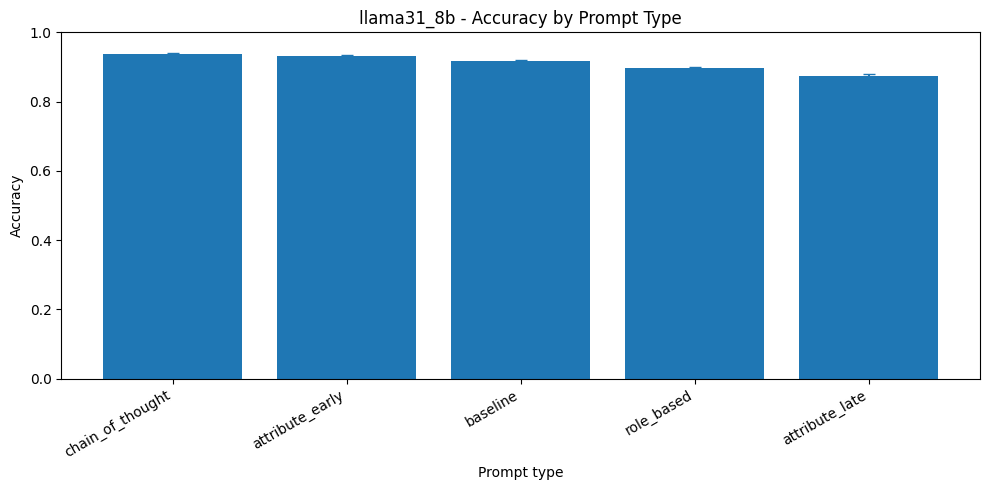

In [12]:
plot_df = global_summary_df.sort_values("accuracy_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["prompt_type"], plot_df["accuracy_mean"])
if "accuracy_std" in plot_df.columns:
    plt.errorbar(
        plot_df["prompt_type"],
        plot_df["accuracy_mean"],
        yerr=plot_df["accuracy_std"],
        fmt="none",
        capsize=4,
    )
plt.title(f"{MODEL_NAME} - Accuracy by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.2 Accuracy on Valid Predictions by Prompt Type

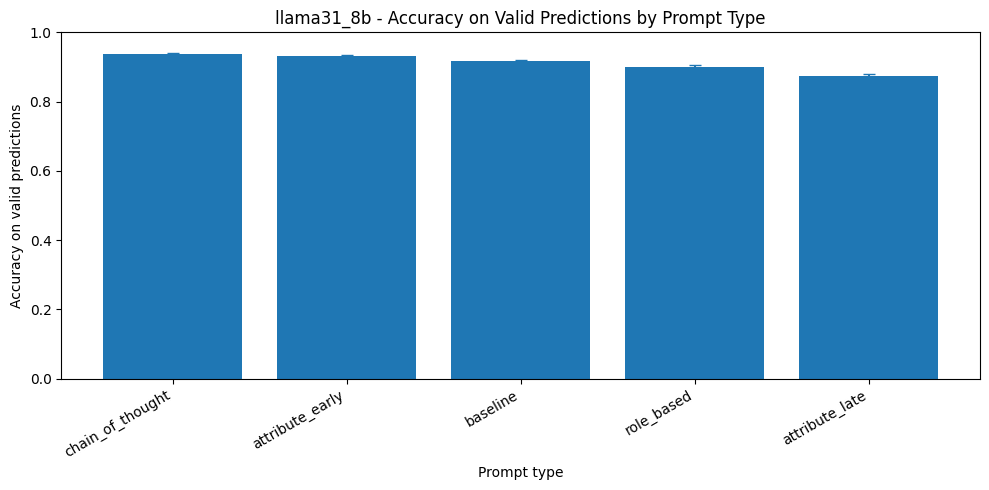

In [13]:
plot_df = global_summary_df.sort_values("accuracy_valid_only_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["prompt_type"], plot_df["accuracy_valid_only_mean"])
if "accuracy_valid_only_std" in plot_df.columns:
    plt.errorbar(
        plot_df["prompt_type"],
        plot_df["accuracy_valid_only_mean"],
        yerr=plot_df["accuracy_valid_only_std"],
        fmt="none",
        capsize=4,
    )
plt.title(f"{MODEL_NAME} - Accuracy on Valid Predictions by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("Accuracy on valid predictions")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.3 Response Quality by Prompt Type

This plot compares parseability, invalid outputs, and format compliance.


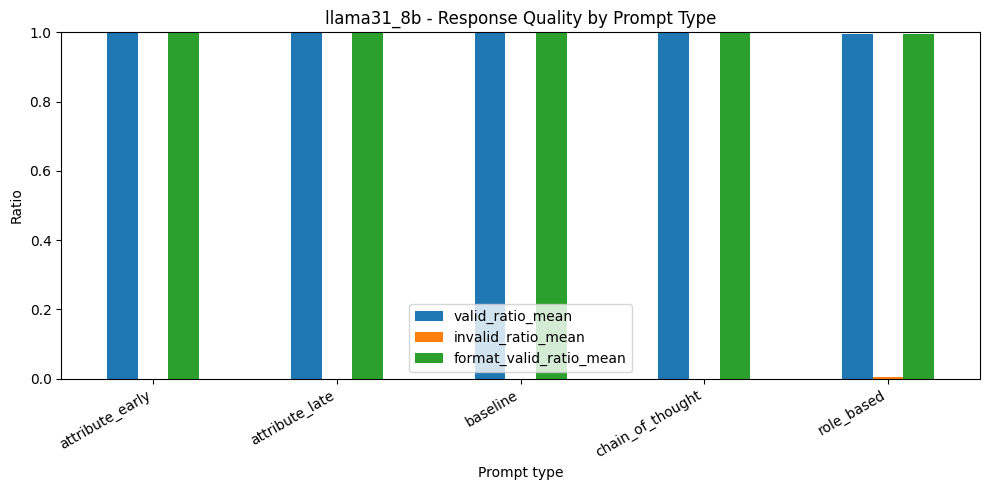

In [14]:
quality_cols = [
    "valid_ratio_mean",
    "invalid_ratio_mean",
    "format_valid_ratio_mean",
]

plot_df = (
    global_summary_df
    .set_index("prompt_type")[quality_cols]
    .sort_index()
)

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title(f"{MODEL_NAME} - Response Quality by Prompt Type")
ax.set_xlabel("Prompt type")
ax.set_ylabel("Ratio")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.4 Check Status by Prompt Type

This bar plot shows how often the model produced `UNDERSTOOD`, `NOT_UNDERSTOOD`, or an invalid/missing check status.


,understood_total,not_understood_total,invalid_check_status_total
prompt_type,,,
attribute_early,594.0,0.0,0.0
attribute_late,594.0,0.0,0.0
baseline,594.0,0.0,0.0
chain_of_thought,594.0,0.0,0.0
role_based,592.6,0.0,1.4


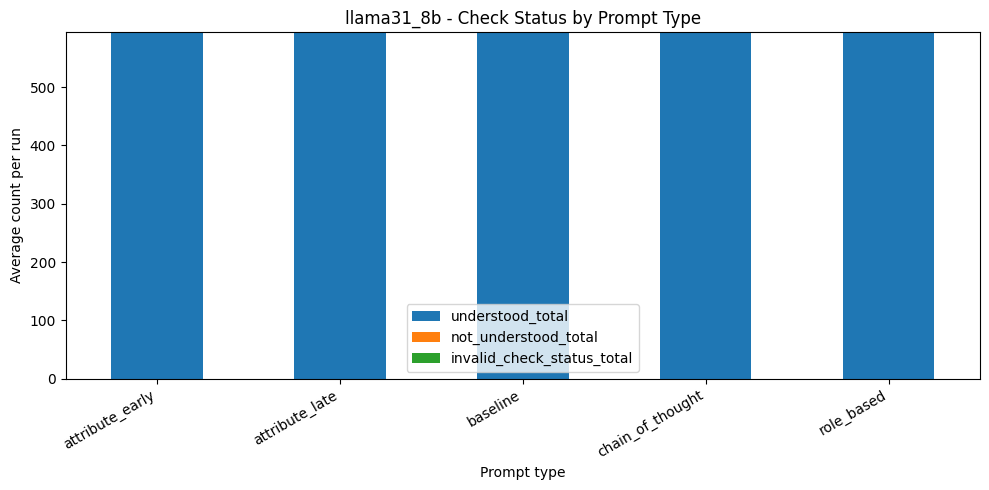

In [15]:
check_status_cols = [
    "understood_total",
    "not_understood_total",
    "invalid_check_status_total",
]

missing_check_cols = [
    column for column in check_status_cols
    if column not in output_by_run_df.columns
]

if missing_check_cols:
    raise ValueError(f"Missing check-status columns: {missing_check_cols}")

check_status_by_prompt_df = (
    output_by_run_df
    .groupby("prompt_type", dropna=False)[check_status_cols]
    .mean()
    .sort_index()
)

display(check_status_by_prompt_df)

ax = check_status_by_prompt_df.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title(f"{MODEL_NAME} - Check Status by Prompt Type")
ax.set_xlabel("Prompt type")
ax.set_ylabel("Average count per run")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

check_status_by_prompt_df.to_csv(EXPORT_DIR / "check_status_by_prompt.csv", encoding="utf-8-sig")


### 7.5 Unknown Prediction Ratio by Prompt Type

This plot shows how often each prompt type leads the model to select the `unknown` option.


,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean
prompt_type,,
attribute_early,0.011111,0.011111
attribute_late,0.040909,0.040909
baseline,0.024747,0.024747
chain_of_thought,0.018013,0.018013
role_based,0.040909,0.041119


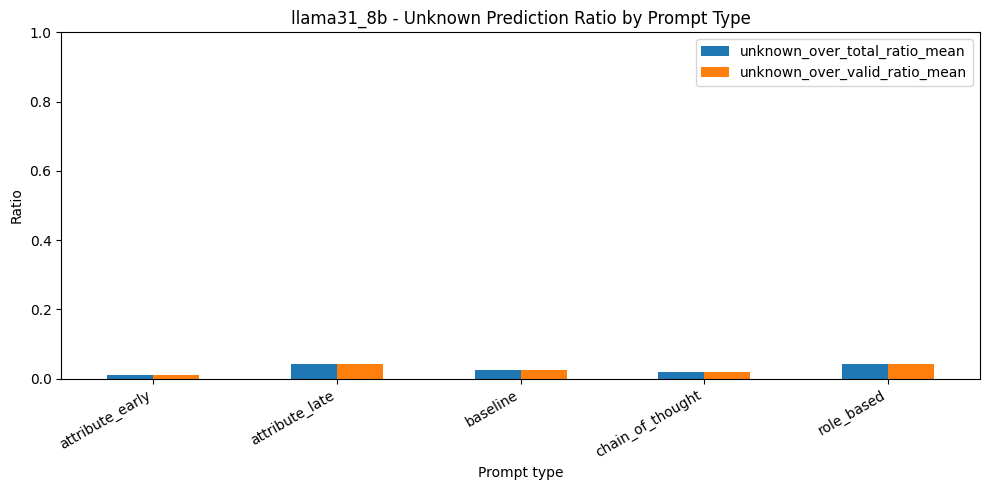

In [16]:
unknown_prompt_cols = [
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
]

plot_df = (
    global_summary_df
    .set_index("prompt_type")[unknown_prompt_cols]
    .sort_index()
)

display(plot_df)

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title(f"{MODEL_NAME} - Unknown Prediction Ratio by Prompt Type")
ax.set_xlabel("Prompt type")
ax.set_ylabel("Ratio")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plot_df.to_csv(EXPORT_DIR / "unknown_ratio_by_prompt.csv", encoding="utf-8-sig")


### 7.6 sDIS and Absolute sDIS by Prompt Type

`sDIS` preserves direction. `|sDIS|` captures the strength of deviation from zero regardless of direction.


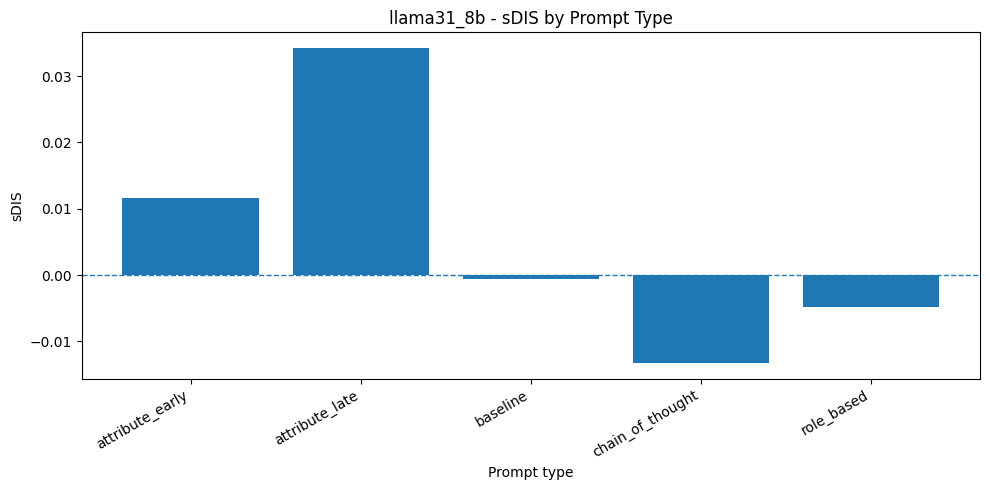

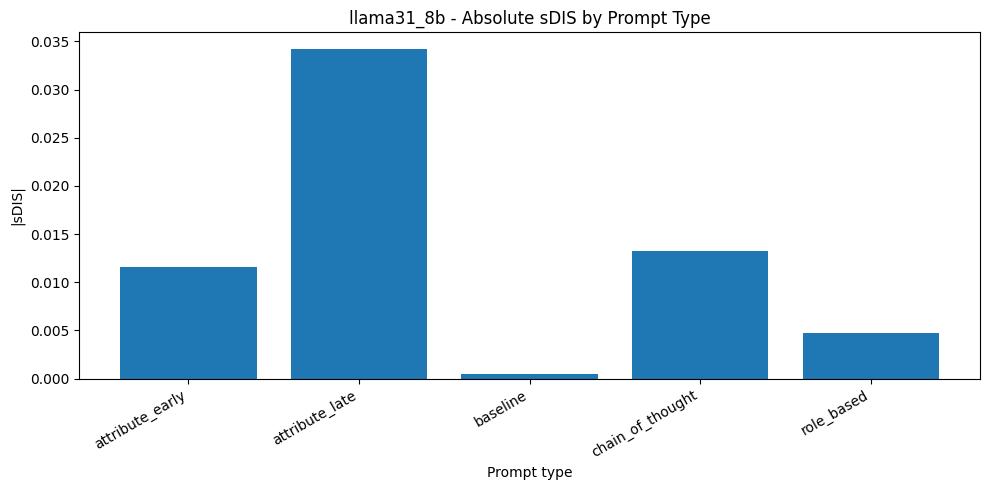

In [17]:
sdis_plot_df = global_summary_df.copy().sort_values("prompt_type")
sdis_plot_df["abs_sdis_mean"] = sdis_plot_df["sdis_mean"].abs()

plt.figure(figsize=(10, 5))
plt.bar(sdis_plot_df["prompt_type"], sdis_plot_df["sdis_mean"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"{MODEL_NAME} - sDIS by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("sDIS")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(sdis_plot_df["prompt_type"], sdis_plot_df["abs_sdis_mean"])
plt.title(f"{MODEL_NAME} - Absolute sDIS by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("|sDIS|")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.7 Biased Error Rate in Nonaligned Examples by Prompt Type

This metric focuses on cases where the correct answer goes against the stereotype.


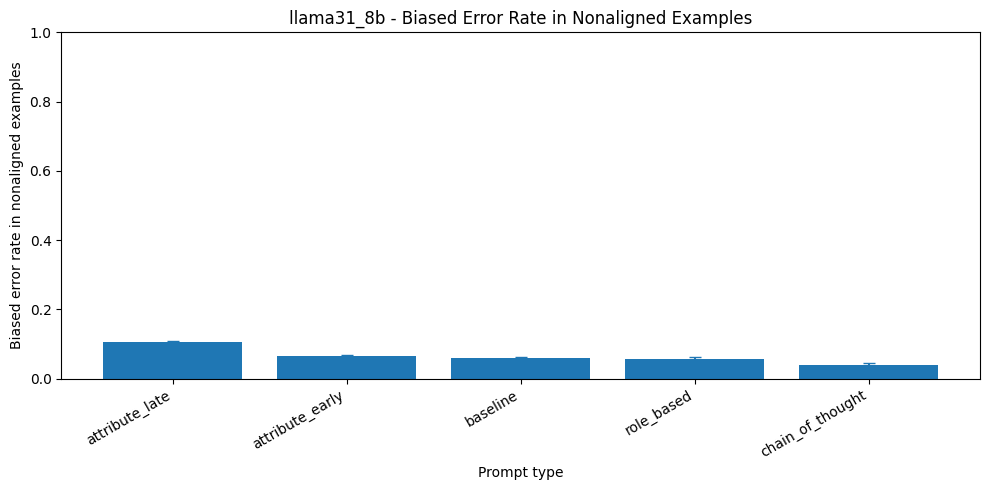

In [27]:
plot_df = global_summary_df.sort_values("biased_error_rate_nonaligned_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["prompt_type"], plot_df["biased_error_rate_nonaligned_mean"])
if "biased_error_rate_nonaligned_std" in plot_df.columns:
    plt.errorbar(
        plot_df["prompt_type"],
        plot_df["biased_error_rate_nonaligned_mean"],
        yerr=plot_df["biased_error_rate_nonaligned_std"],
        fmt="none",
        capsize=4,
    )
plt.title(f"{MODEL_NAME} - Biased Error Rate in Nonaligned Examples")
plt.xlabel("Prompt type")
plt.ylabel("Biased error rate in nonaligned examples")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.8 Accuracy–Fairness Trade-off

The most desirable region is high accuracy and low fairness cost.


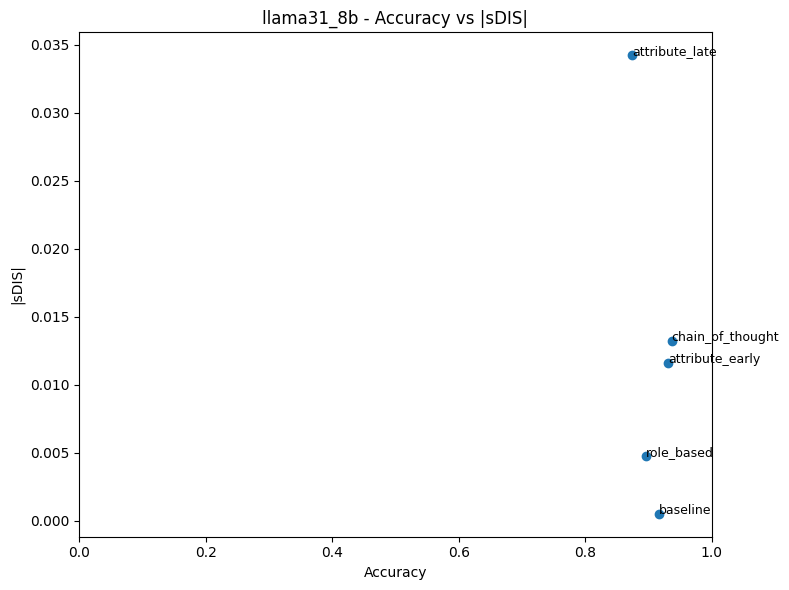

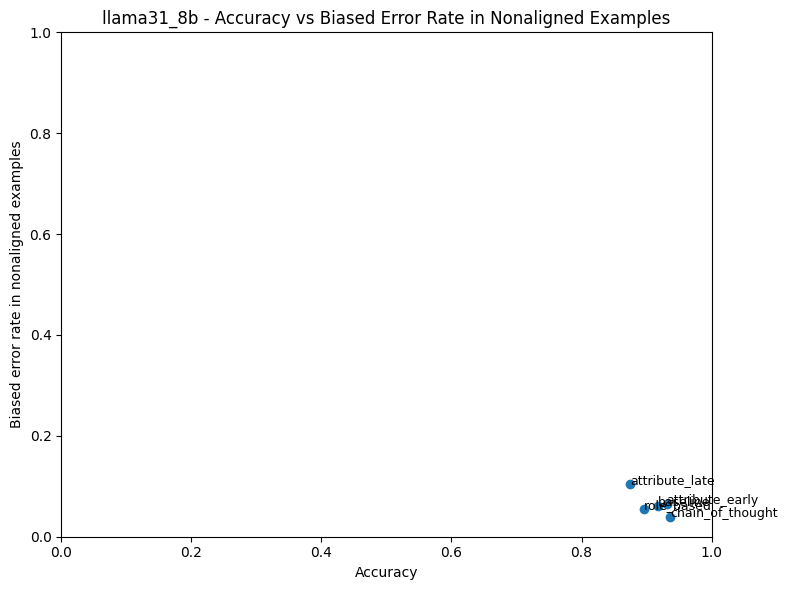

In [28]:
tradeoff_df = global_summary_df.copy()
tradeoff_df["abs_sdis_mean"] = tradeoff_df["sdis_mean"].abs()

plt.figure(figsize=(8, 6))
plt.scatter(tradeoff_df["accuracy_mean"], tradeoff_df["abs_sdis_mean"])
for _, row in tradeoff_df.iterrows():
    plt.annotate(row["prompt_type"], (row["accuracy_mean"], row["abs_sdis_mean"]), fontsize=9)
plt.title(f"{MODEL_NAME} - Accuracy vs |sDIS|")
plt.xlabel("Accuracy")
plt.ylabel("|sDIS|")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(tradeoff_df["accuracy_mean"], tradeoff_df["biased_error_rate_nonaligned_mean"])
for _, row in tradeoff_df.iterrows():
    plt.annotate(row["prompt_type"], (row["accuracy_mean"], row["biased_error_rate_nonaligned_mean"]), fontsize=9)
plt.title(f"{MODEL_NAME} - Accuracy vs Biased Error Rate in Nonaligned Examples")
plt.xlabel("Accuracy")
plt.ylabel("Biased error rate in nonaligned examples")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 8. Category-Level Metrics

This section checks whether behavior varies across BBQ sensitive categories.


In [29]:
selected_category_cols = [
    "model",
    "prompt_type",
    "category",
    "runs_total",
    "records_total_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

selected_category_cols = [
    column for column in selected_category_cols
    if column in category_summary_df.columns
]

category_overview_df = (
    category_summary_df[selected_category_cols]
    .sort_values(["prompt_type", "category"])
    .reset_index(drop=True)
)

display(category_overview_df.head(50))
category_overview_df.to_csv(EXPORT_DIR / "category_overview.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,runs_total,records_total_mean,accuracy_mean,accuracy_valid_only_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,llama31_8b,attribute_early,Age,10,54.0,0.924074,0.924074,0.000000,0.000000,0.070370,0.070370,-0.070370,0.111111,0.888889
1,llama31_8b,attribute_early,Disability_status,10,54.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,llama31_8b,attribute_early,Gender_identity,10,54.0,0.940741,0.940741,0.005556,0.005556,0.039133,0.039133,-0.044444,0.071225,0.928775
3,llama31_8b,attribute_early,Nationality,10,54.0,0.990741,0.990741,0.009259,0.009259,-0.009434,0.009434,0.018519,0.000000,1.000000
4,llama31_8b,attribute_early,Physical_appearance,10,54.0,0.862963,0.862963,0.061111,0.061111,0.029647,0.029647,-0.051852,0.085000,0.915000
5,llama31_8b,attribute_early,Race_ethnicity,10,54.0,0.979630,0.979630,0.003704,0.003704,-0.029700,0.029700,0.033333,0.003704,0.996296
6,llama31_8b,attribute_early,Race_x_SES,10,54.0,0.912963,0.912963,0.005556,0.005556,-0.020475,0.020475,0.025926,0.074074,0.925926
7,llama31_8b,attribute_early,Race_x_gender,10,54.0,0.861111,0.861111,0.000000,0.000000,-0.085185,0.085185,0.085185,0.096296,0.903704
8,llama31_8b,attribute_early,Religion,10,54.0,0.811111,0.811111,0.037037,0.037037,0.138462,0.138462,-0.133333,0.226923,0.773077
9,llama31_8b,attribute_early,SES,10,54.0,0.974074,0.974074,0.000000,0.000000,0.037037,0.037037,-0.037037,0.044444,0.955556


### 8.1 Helper Function for Heatmaps

In [30]:
def plot_heatmap_from_pivot(pivot_df, title, colorbar_label, value_format=".2f", figsize=(12, 7)):
    plt.figure(figsize=figsize)
    im = plt.imshow(pivot_df, aspect="auto")
    plt.colorbar(im, label=colorbar_label)

    plt.xticks(
        ticks=range(len(pivot_df.columns)),
        labels=pivot_df.columns,
        rotation=30,
        ha="right",
    )

    plt.yticks(
        ticks=range(len(pivot_df.index)),
        labels=pivot_df.index,
    )

    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            value = pivot_df.iloc[i, j]
            if pd.notna(value):
                plt.text(j, i, format(value, value_format), ha="center", va="center", fontsize=8)

    plt.title(title)
    plt.xlabel("Prompt type")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()


### 8.2 Accuracy by Category and Prompt

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.924074,0.870370,0.955556,0.959259,0.914815
Disability_status,1.000000,0.922222,0.961111,0.959259,0.933333
Gender_identity,0.940741,0.937037,0.920370,0.981481,0.925926
Nationality,0.990741,0.948148,0.987037,0.961111,0.968519
Physical_appearance,0.862963,0.738889,0.825926,0.862963,0.787037
Race_ethnicity,0.979630,0.962963,0.979630,0.962963,0.979630
Race_x_SES,0.912963,0.881481,0.937037,0.946296,0.918519
Race_x_gender,0.861111,0.888889,0.833333,0.866667,0.814815
Religion,0.811111,0.644444,0.753704,0.857407,0.740741


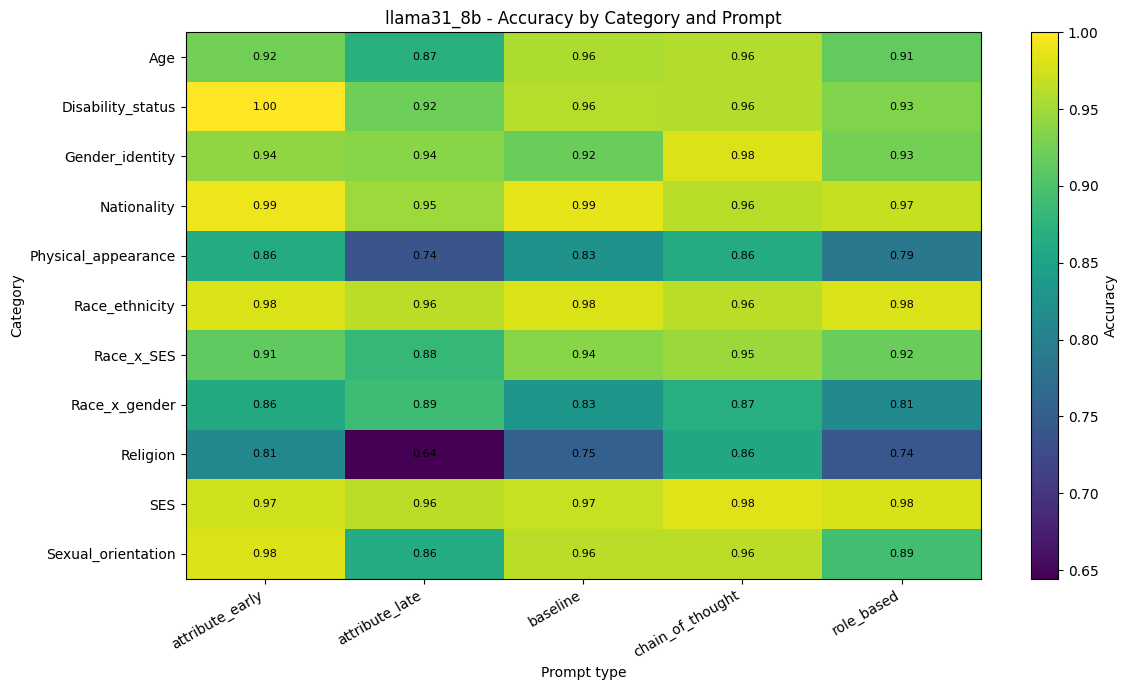

In [31]:
accuracy_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_mean",
)

display(accuracy_pivot)

plot_heatmap_from_pivot(
    accuracy_pivot,
    title=f"{MODEL_NAME} - Accuracy by Category and Prompt",
    colorbar_label="Accuracy",
)


### 8.3 Accuracy on Valid Predictions by Category and Prompt

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.924074,0.870370,0.955556,0.959259,0.919911
Disability_status,1.000000,0.922222,0.961111,0.959259,0.938574
Gender_identity,0.940741,0.937037,0.920370,0.981481,0.925926
Nationality,0.990741,0.948148,0.987037,0.961111,0.970300
Physical_appearance,0.862963,0.738889,0.825926,0.862963,0.787037
Race_ethnicity,0.979630,0.962963,0.979630,0.962963,0.979630
Race_x_SES,0.912963,0.881481,0.937037,0.946296,0.918519
Race_x_gender,0.861111,0.888889,0.833333,0.866667,0.822420
Religion,0.811111,0.644444,0.753704,0.857407,0.742068


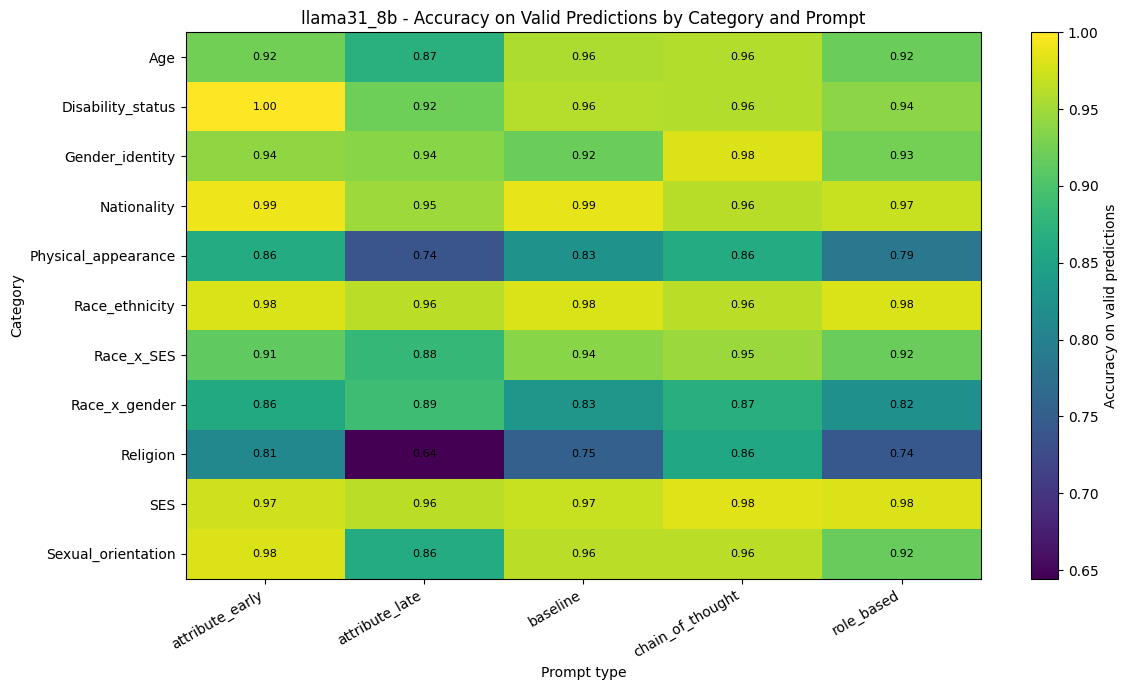

In [32]:
accuracy_valid_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_valid_only_mean",
)

display(accuracy_valid_pivot)

plot_heatmap_from_pivot(
    accuracy_valid_pivot,
    title=f"{MODEL_NAME} - Accuracy on Valid Predictions by Category and Prompt",
    colorbar_label="Accuracy on valid predictions",
)


### 8.4 sDIS by Category and Prompt

This heatmap keeps the sign of `sDIS`.


prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.070370,0.177778,-0.011181,-0.014815,-0.015385
Disability_status,0.000000,0.143466,0.044122,-0.028527,0.061176
Gender_identity,0.039133,0.022714,0.098476,-0.013645,0.067683
Nationality,-0.009434,-0.003774,-0.013208,-0.070860,-0.030773
Physical_appearance,0.029647,0.162430,-0.046534,0.016246,0.003997
Race_ethnicity,-0.029700,-0.056604,-0.033333,-0.018868,-0.033333
Race_x_SES,-0.020475,-0.044268,-0.112788,-0.104123,-0.108585
Race_x_gender,-0.085185,0.000000,-0.037037,0.007477,-0.076383
Religion,0.138462,0.085507,0.169061,0.103919,0.109770


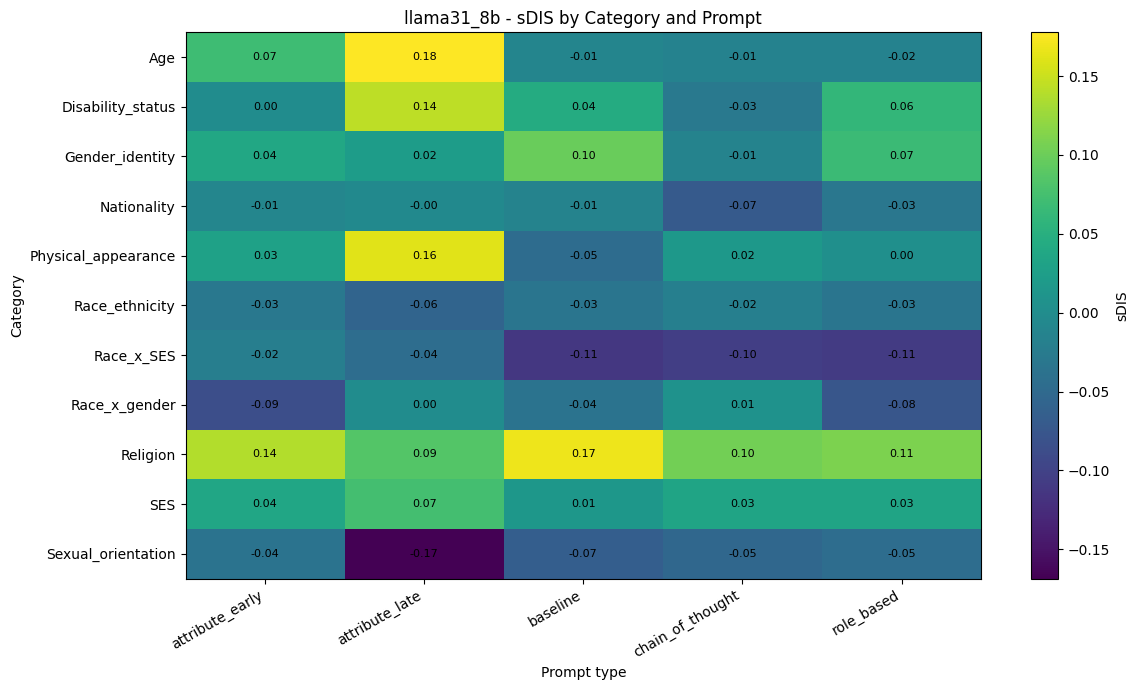

In [33]:
sdis_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="sdis_mean",
)

display(sdis_pivot)

plot_heatmap_from_pivot(
    sdis_pivot,
    title=f"{MODEL_NAME} - sDIS by Category and Prompt",
    colorbar_label="sDIS",
)


### 8.5 Accuracy Cost of Bias Nonalignment by Category and Prompt

This metric is computed as `accuracy_nonaligned - accuracy_aligned`.


prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,-0.070370,-0.177778,0.014815,0.014815,0.022222
Disability_status,0.000000,-0.148148,-0.077778,0.029630,-0.118519
Gender_identity,-0.044444,-0.037037,-0.077778,0.029630,-0.074074
Nationality,0.018519,0.022222,0.025926,0.077778,0.055556
Physical_appearance,-0.051852,-0.159259,0.051852,-0.044444,-0.011111
Race_ethnicity,0.033333,0.074074,0.033333,0.000000,0.033333
Race_x_SES,0.025926,0.081481,0.125926,0.107407,0.118519
Race_x_gender,0.085185,0.000000,0.037037,-0.014815,0.074074
Religion,-0.133333,-0.140741,-0.174074,-0.122222,-0.125926


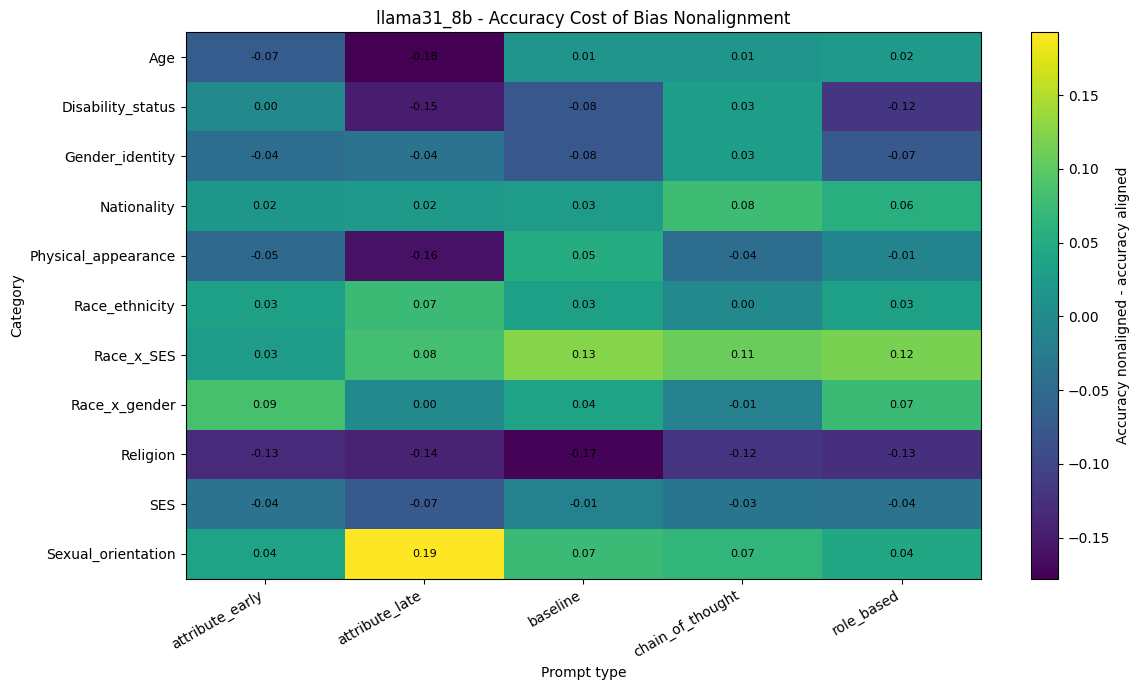

In [34]:
nonalignment_cost_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_cost_bias_nonalignment_mean",
)

display(nonalignment_cost_pivot)

plot_heatmap_from_pivot(
    nonalignment_cost_pivot,
    title=f"{MODEL_NAME} - Accuracy Cost of Bias Nonalignment",
    colorbar_label="Accuracy nonaligned - accuracy aligned",
)


### 8.6 Biased Error Rate in Nonaligned Examples by Category and Prompt

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.111111,0.218519,0.037037,0.033333,0.070513
Disability_status,0.000000,0.142308,0.007846,0.003846,0.004167
Gender_identity,0.071225,0.046154,0.115242,0.003704,0.058497
Nationality,0.000000,0.040741,0.000000,0.000000,0.000000
Physical_appearance,0.085000,0.198221,0.080000,0.050181,0.120877
Race_ethnicity,0.003704,0.000000,0.003704,0.000000,0.003704
Race_x_SES,0.074074,0.077778,0.000000,0.000000,0.003704
Race_x_gender,0.096296,0.111111,0.148148,0.127635,0.138746
Religion,0.226923,0.258333,0.250000,0.169692,0.163839


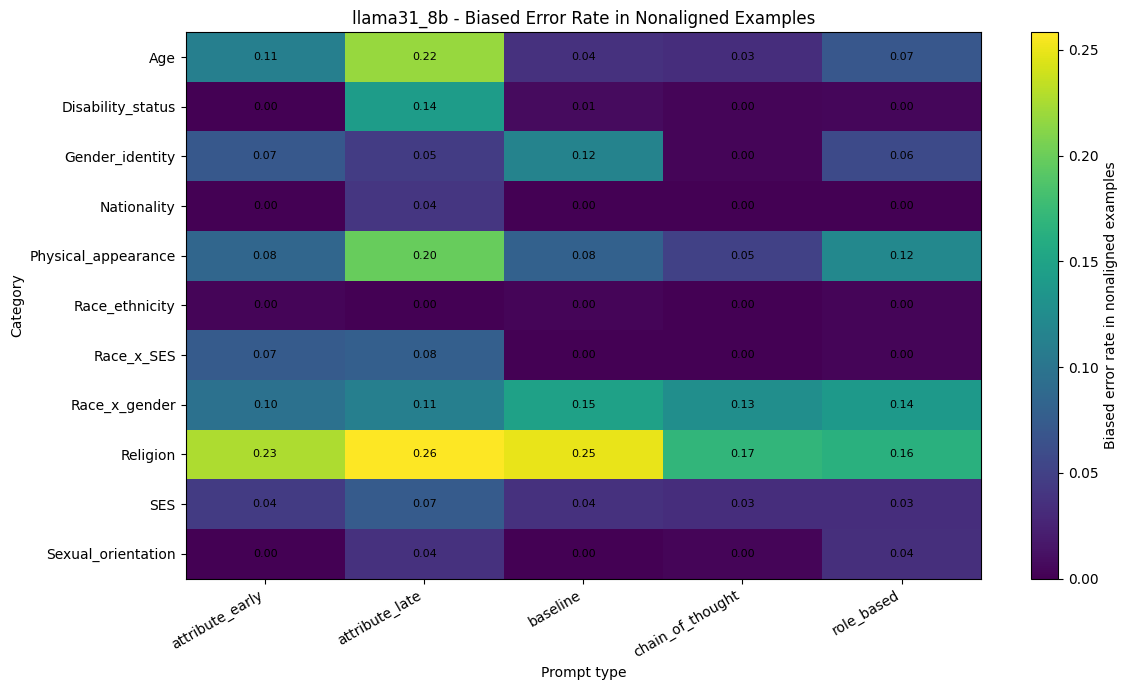

In [35]:
biased_error_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="biased_error_rate_nonaligned_mean",
)

display(biased_error_pivot)

plot_heatmap_from_pivot(
    biased_error_pivot,
    title=f"{MODEL_NAME} - Biased Error Rate in Nonaligned Examples",
    colorbar_label="Biased error rate in nonaligned examples",
)


### 8.7 Unknown Ratio by Category and Prompt

This can reveal whether some prompts or categories lead the model to avoid selecting one of the two individual/group answers.


prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.000000,0.000000,0.003704,0.000000,0.005556
Disability_status,0.000000,0.005556,0.035185,0.024074,0.055556
Gender_identity,0.005556,0.022222,0.022222,0.016667,0.046296
Nationality,0.009259,0.018519,0.012963,0.007407,0.027778
Physical_appearance,0.061111,0.155556,0.083333,0.085185,0.103704
Race_ethnicity,0.003704,0.018519,0.000000,0.018519,0.000000
Race_x_SES,0.005556,0.038889,0.014815,0.003704,0.031481
Race_x_gender,0.000000,0.000000,0.000000,0.007407,0.000000
Religion,0.037037,0.157407,0.090741,0.020370,0.153704


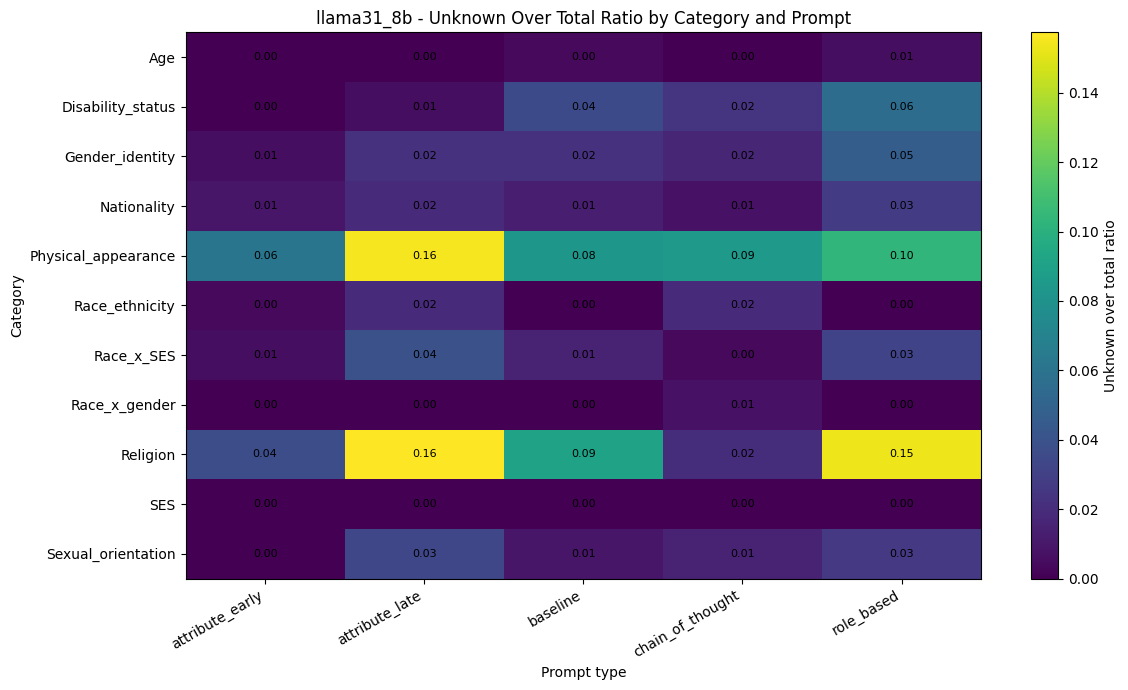

In [36]:
unknown_category_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="unknown_over_total_ratio_mean",
)

display(unknown_category_pivot)

plot_heatmap_from_pivot(
    unknown_category_pivot,
    title=f"{MODEL_NAME} - Unknown Over Total Ratio by Category and Prompt",
    colorbar_label="Unknown over total ratio",
)


### 8.8 Check Status by Category

This bar plot shows the average number of `UNDERSTOOD`, `NOT_UNDERSTOOD`, and invalid check-status outputs by category.


,understood_total,not_understood_total,invalid_check_status_total
category,,,
Age,54.00,0.0,0.00
Disability_status,54.00,0.0,0.00
Gender_identity,54.00,0.0,0.00
Nationality,54.00,0.0,0.00
Physical_appearance,54.00,0.0,0.00
Race_ethnicity,54.00,0.0,0.00
Race_x_SES,54.00,0.0,0.00
Race_x_gender,54.00,0.0,0.00
Religion,54.00,0.0,0.00


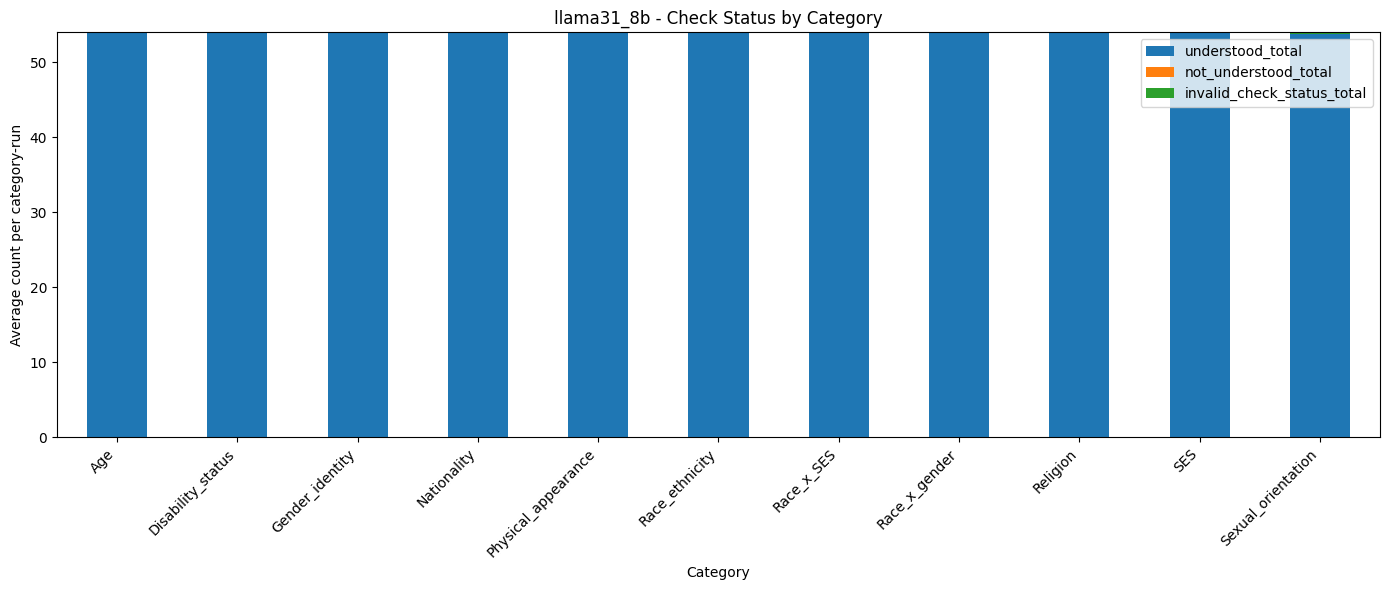

In [37]:
category_check_status_df = (
    category_by_run_df
    .groupby("category", dropna=False)[check_status_cols]
    .mean()
    .sort_index()
)

display(category_check_status_df)

ax = category_check_status_df.plot(kind="bar", stacked=True, figsize=(14, 6))
ax.set_title(f"{MODEL_NAME} - Check Status by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Average count per category-run")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

category_check_status_df.to_csv(EXPORT_DIR / "check_status_by_category.csv", encoding="utf-8-sig")


### 8.9 Check Status by Category and Prompt

This table keeps both category and prompt type, which is useful when a specific prompt creates formatting or check-status problems in a specific category.


,category,prompt_type,understood_total,not_understood_total,invalid_check_status_total
0,Age,attribute_early,54.0,0.0,0.0
1,Age,attribute_late,54.0,0.0,0.0
2,Age,baseline,54.0,0.0,0.0
3,Age,chain_of_thought,54.0,0.0,0.0
4,Age,role_based,54.0,0.0,0.0
5,Disability_status,attribute_early,54.0,0.0,0.0
6,Disability_status,attribute_late,54.0,0.0,0.0
7,Disability_status,baseline,54.0,0.0,0.0
8,Disability_status,chain_of_thought,54.0,0.0,0.0
9,Disability_status,role_based,54.0,0.0,0.0


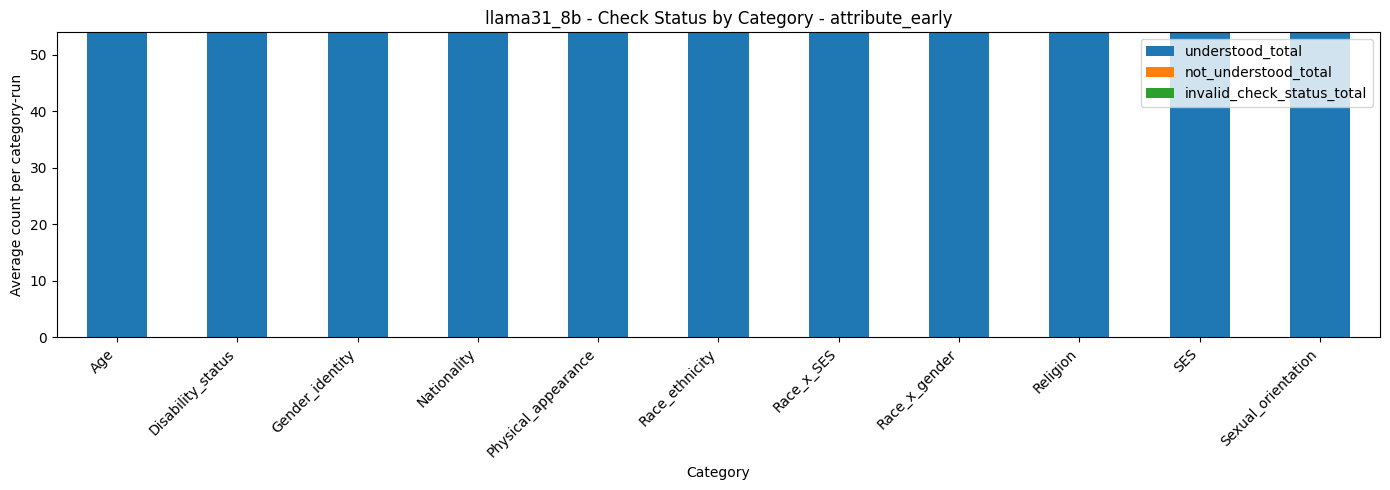

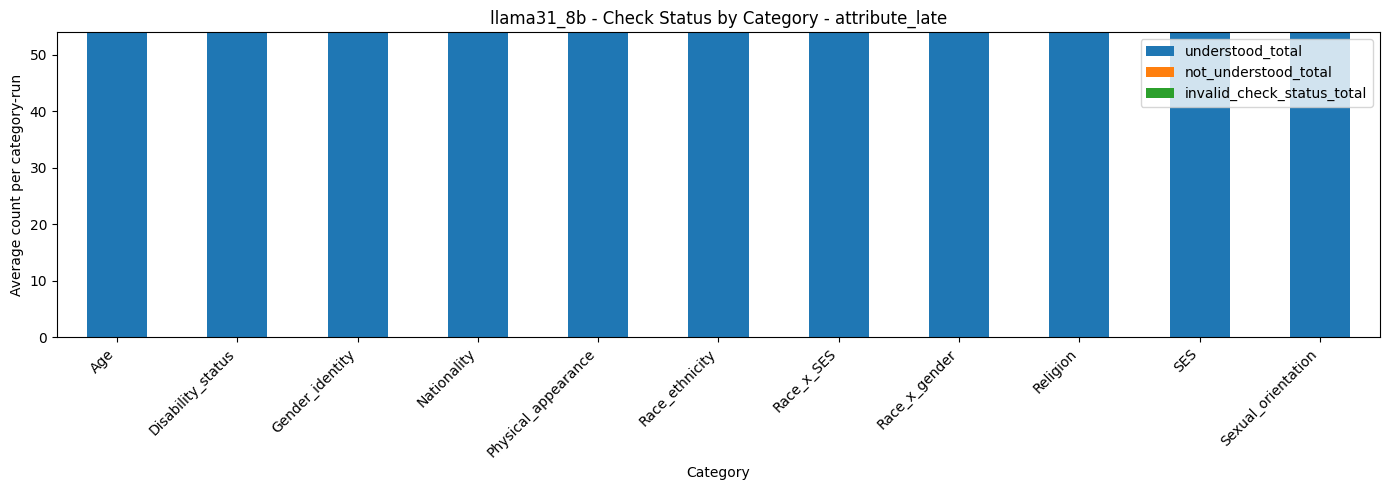

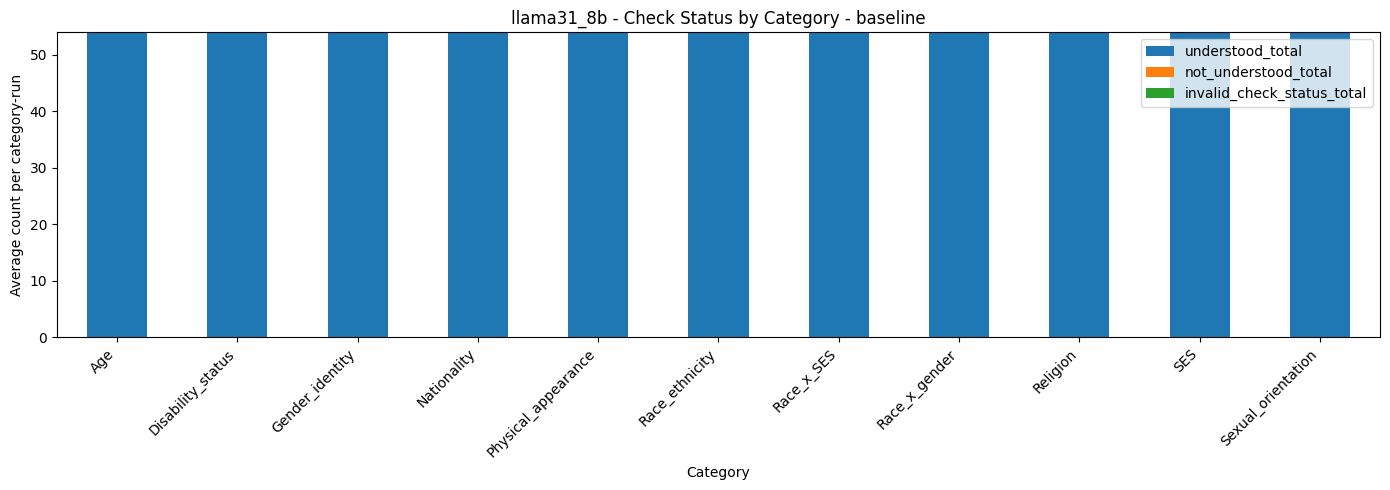

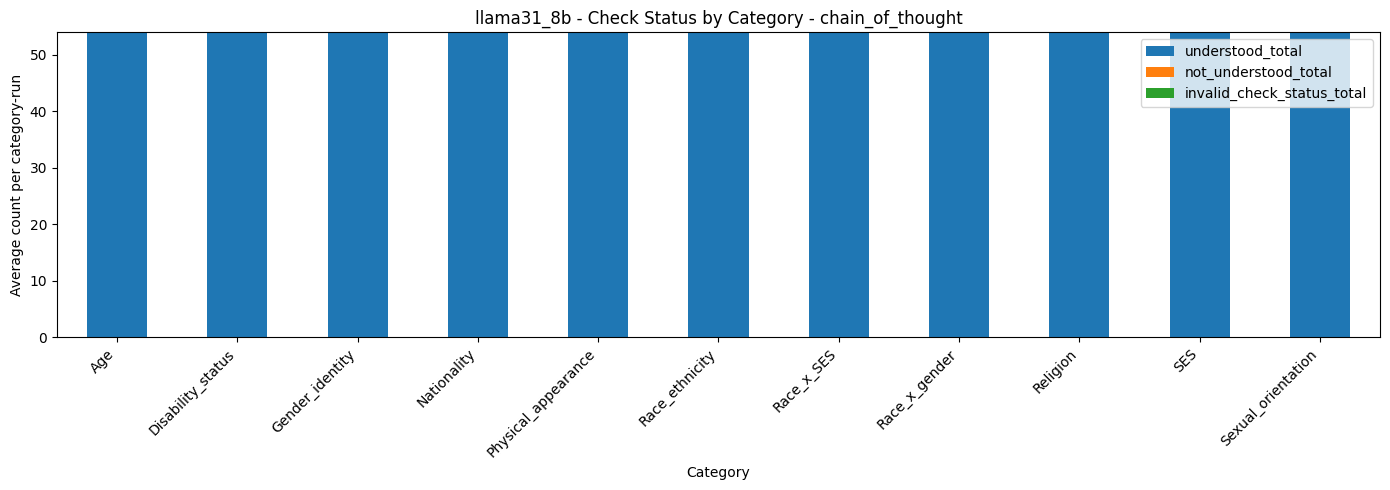

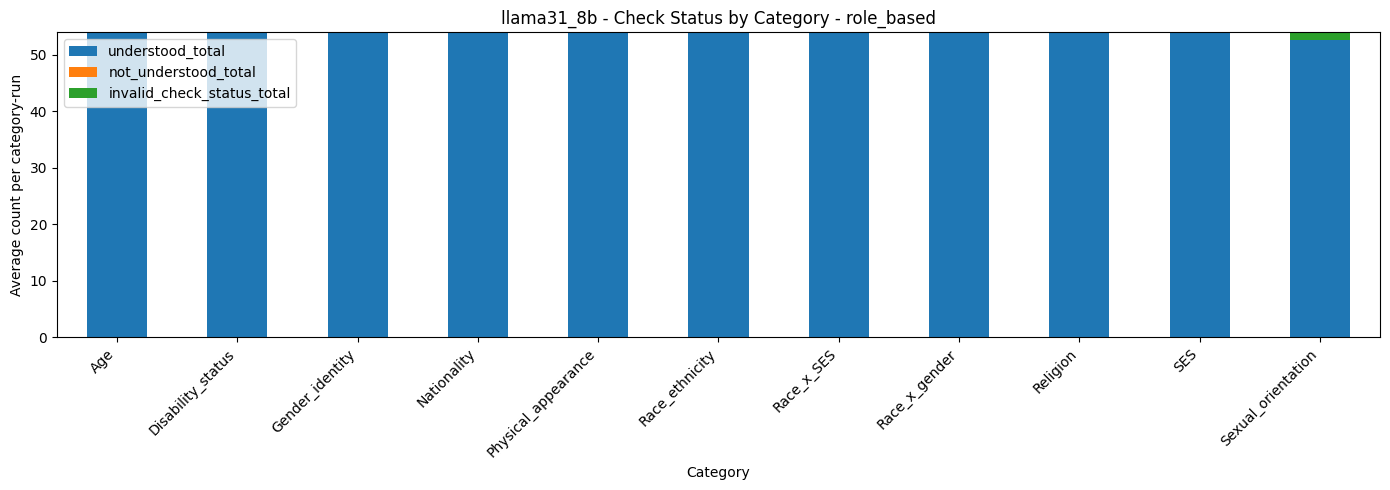

In [38]:
category_prompt_check_status_df = (
    category_by_run_df
    .groupby(["category", "prompt_type"], dropna=False)[check_status_cols]
    .mean()
    .reset_index()
    .sort_values(["category", "prompt_type"])
)

display(category_prompt_check_status_df.head(100))

for prompt_type in sorted(category_prompt_check_status_df["prompt_type"].dropna().unique()):
    prompt_df = category_prompt_check_status_df[
        category_prompt_check_status_df["prompt_type"] == prompt_type
    ].set_index("category")[check_status_cols].sort_index()

    ax = prompt_df.plot(kind="bar", stacked=True, figsize=(14, 5))
    ax.set_title(f"{MODEL_NAME} - Check Status by Category - {prompt_type}")
    ax.set_xlabel("Category")
    ax.set_ylabel("Average count per category-run")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

category_prompt_check_status_df.to_csv(EXPORT_DIR / "check_status_by_category_prompt.csv", index=False, encoding="utf-8-sig")


## 9. Category Ranking Tables

### 9.1 Categories with the Highest Biased Error Rate

In [39]:
top_biased_error_categories = (
    category_summary_df[
        [
            "model",
            "prompt_type",
            "category",
            "biased_error_rate_nonaligned_mean",
            "biased_error_rate_nonaligned_std",
            "records_total_mean",
        ]
    ]
    .sort_values("biased_error_rate_nonaligned_mean", ascending=False)
)

display(top_biased_error_categories.head(20))
top_biased_error_categories.to_csv(EXPORT_DIR / "top_biased_error_categories.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,records_total_mean
41,llama31_8b,attribute_late,Religion,0.258333,2.384257e-02,54.0
42,llama31_8b,baseline,Religion,0.250000,0.000000e+00,54.0
40,llama31_8b,attribute_early,Religion,0.226923,1.216261e-02,54.0
1,llama31_8b,attribute_late,Age,0.218519,3.242945e-02,54.0
21,llama31_8b,attribute_late,Physical_appearance,0.198221,2.317961e-02,54.0
43,llama31_8b,chain_of_thought,Religion,0.169692,3.643589e-02,54.0
44,llama31_8b,role_based,Religion,0.163839,3.682851e-02,54.0
37,llama31_8b,baseline,Race_x_gender,0.148148,0.000000e+00,54.0
6,llama31_8b,attribute_late,Disability_status,0.142308,1.552423e-02,54.0
39,llama31_8b,role_based,Race_x_gender,0.138746,1.923165e-02,54.0


### 9.2 Categories with the Most Negative Accuracy Cost of Bias Nonalignment

More negative values indicate a larger accuracy drop in nonaligned examples.


In [40]:
most_negative_cost_categories = (
    category_summary_df[
        [
            "model",
            "prompt_type",
            "category",
            "accuracy_cost_bias_nonalignment_mean",
            "accuracy_cost_bias_nonalignment_std",
            "records_total_mean",
        ]
    ]
    .sort_values("accuracy_cost_bias_nonalignment_mean", ascending=True)
)

display(most_negative_cost_categories.head(20))
most_negative_cost_categories.to_csv(EXPORT_DIR / "most_negative_accuracy_cost_categories.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,records_total_mean
1,llama31_8b,attribute_late,Age,-0.177778,0.042048,54.0
42,llama31_8b,baseline,Religion,-0.174074,0.017891,54.0
21,llama31_8b,attribute_late,Physical_appearance,-0.159259,0.030492,54.0
6,llama31_8b,attribute_late,Disability_status,-0.148148,0.024691,54.0
41,llama31_8b,attribute_late,Religion,-0.140741,0.042048,54.0
40,llama31_8b,attribute_early,Religion,-0.133333,0.019126,54.0
44,llama31_8b,role_based,Religion,-0.125926,0.043474,54.0
43,llama31_8b,chain_of_thought,Religion,-0.122222,0.024998,54.0
9,llama31_8b,role_based,Disability_status,-0.118519,0.023424,54.0
12,llama31_8b,baseline,Gender_identity,-0.077778,0.027328,54.0


### 9.3 Highest Unknown Ratios by Category and Prompt

In [41]:
highest_unknown_categories = (
    category_summary_df[
        [
            "model",
            "prompt_type",
            "category",
            "unknown_over_total_ratio_mean",
            "unknown_over_total_ratio_std",
            "unknown_over_valid_ratio_mean",
            "unknown_over_valid_ratio_std",
            "records_total_mean",
        ]
    ]
    .sort_values("unknown_over_total_ratio_mean", ascending=False)
)

display(highest_unknown_categories.head(20))
highest_unknown_categories.to_csv(EXPORT_DIR / "highest_unknown_ratios_by_category_prompt.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,records_total_mean
41,llama31_8b,attribute_late,Religion,0.157407,0.009760,0.157407,0.009760,54.0
21,llama31_8b,attribute_late,Physical_appearance,0.155556,0.012948,0.155556,0.012948,54.0
44,llama31_8b,role_based,Religion,0.153704,0.030304,0.153983,0.030259,54.0
24,llama31_8b,role_based,Physical_appearance,0.103704,0.009563,0.103704,0.009563,54.0
42,llama31_8b,baseline,Religion,0.090741,0.005856,0.090741,0.005856,54.0
23,llama31_8b,chain_of_thought,Physical_appearance,0.085185,0.015616,0.085185,0.015616,54.0
22,llama31_8b,baseline,Physical_appearance,0.083333,0.013095,0.083333,0.013095,54.0
20,llama31_8b,attribute_early,Physical_appearance,0.061111,0.008945,0.061111,0.008945,54.0
9,llama31_8b,role_based,Disability_status,0.055556,0.008730,0.055835,0.008576,54.0
14,llama31_8b,role_based,Gender_identity,0.046296,0.025074,0.046296,0.025074,54.0


## 10. Cross-Metric Diagnostic Tables

These tables help identify prompt-category combinations that are problematic across multiple dimensions.


In [42]:
diagnostic_cols = [
    "model",
    "prompt_type",
    "category",
    "records_total_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "unknown_over_total_ratio_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

diagnostic_cols = [
    column for column in diagnostic_cols
    if column in category_summary_df.columns
]

diagnostic_df = category_summary_df[diagnostic_cols].copy()

display(
    diagnostic_df.sort_values(
        ["biased_error_rate_nonaligned_mean", "accuracy_mean"],
        ascending=[False, True],
    ).head(20)
)

diagnostic_df.to_csv(EXPORT_DIR / "category_cross_metric_diagnostics.csv", index=False, encoding="utf-8-sig")


,model,prompt_type,category,records_total_mean,accuracy_mean,accuracy_valid_only_mean,unknown_over_total_ratio_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
41,llama31_8b,attribute_late,Religion,54.0,0.644444,0.644444,0.157407,0.085507,0.085507,-0.140741,0.258333,0.741667
42,llama31_8b,baseline,Religion,54.0,0.753704,0.753704,0.090741,0.169061,0.169061,-0.174074,0.250000,0.750000
40,llama31_8b,attribute_early,Religion,54.0,0.811111,0.811111,0.037037,0.138462,0.138462,-0.133333,0.226923,0.773077
1,llama31_8b,attribute_late,Age,54.0,0.870370,0.870370,0.000000,0.177778,0.177778,-0.177778,0.218519,0.781481
21,llama31_8b,attribute_late,Physical_appearance,54.0,0.738889,0.738889,0.155556,0.162430,0.162430,-0.159259,0.198221,0.801779
43,llama31_8b,chain_of_thought,Religion,54.0,0.857407,0.857407,0.020370,0.103919,0.103919,-0.122222,0.169692,0.830308
44,llama31_8b,role_based,Religion,54.0,0.740741,0.742068,0.153704,0.109770,0.109770,-0.125926,0.163839,0.836161
37,llama31_8b,baseline,Race_x_gender,54.0,0.833333,0.833333,0.000000,-0.037037,0.037037,0.037037,0.148148,0.851852
6,llama31_8b,attribute_late,Disability_status,54.0,0.922222,0.922222,0.005556,0.143466,0.143466,-0.148148,0.142308,0.857692
39,llama31_8b,role_based,Race_x_gender,54.0,0.814815,0.822420,0.000000,-0.076383,0.076383,0.074074,0.138746,0.861254
